# **1. Problem Statement**
- What makes a TikTok video go viral?
- Are verified users more successful?

## **Dataset Description**

| Column | Type | Description |
|--------|------|-------------|
| # | int | TikTok assigned number for video with claim/opinion |
| claim_status | object | Opinion or claim status |
| video_id | int | Unique video ID |
| video_duration_sec | int | Duration in seconds |
| video_transcription_text | object | Transcribed text |
| verified_status | object | Verified or not verified |
| author_ban_status | object | Active / under scrutiny / banned |
| video_view_count | float | Total views |
| video_like_count | float | Total likes |
| video_share_count | float | Total shares |
| video_download_count | float | Total downloads |
| video_comment_count | float | Total comments |

# **2. Defining and uploading dataset**


In [421]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("tiktok_dataset.csv")
print(df.head())

   # claim_status    video_id  video_duration_sec  \
0  1        claim  7017666017                  59   
1  2        claim  4014381136                  32   
2  3        claim  9859838091                  31   
3  4        claim  1866847991                  25   
4  5        claim  7105231098                  19   

                            video_transcription_text verified_status  \
0  someone shared with me that drone deliveries a...    not verified   
1  someone shared with me that there are more mic...    not verified   
2  someone shared with me that american industria...    not verified   
3  someone shared with me that the metro of st. p...    not verified   
4  someone shared with me that the number of busi...    not verified   

  author_ban_status  video_view_count  video_like_count  video_share_count  \
0      under review          343296.0           19425.0              241.0   
1            active          140877.0           77355.0            19034.0   
2            a

# **3. Data Cleaning**


## Check for missing data

In [422]:
for i in df.columns:
    null_rate = df[i].isna().sum() / len(df) * 100 
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

claim_status null rate: 1.54%
video_transcription_text null rate: 1.54%
video_view_count null rate: 1.54%
video_like_count null rate: 1.54%
video_share_count null rate: 1.54%
video_download_count null rate: 1.54%
video_comment_count null rate: 1.54%


## Check for duplicates

In [423]:
df.duplicated().sum()

0

## Check the data types of the columns

In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


## Clean the data

In [425]:
# Drop unnecessary column
df = df.drop(columns=["#"])

# Convert categorical columns to category data type
cat_cols = ["claim_status", "verified_status", "author_ban_status"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Clean text column
df["video_transcription_text"] = df["video_transcription_text"].astype("string").str.strip()

# Handle missing values in numerical columns
num_cols = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_download_count",
    "video_comment_count"
]
df[num_cols] = df[num_cols].astype("Int64")  # keeps NaN

# Handle missing values in categorical columns
df["claim_status"] = df["claim_status"].cat.add_categories("unknown").fillna("unknown")

In [426]:
# Final check of data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   claim_status              19382 non-null  category
 1   video_id                  19382 non-null  int64   
 2   video_duration_sec        19382 non-null  int64   
 3   video_transcription_text  19084 non-null  string  
 4   verified_status           19382 non-null  category
 5   author_ban_status         19382 non-null  category
 6   video_view_count          19084 non-null  Int64   
 7   video_like_count          19084 non-null  Int64   
 8   video_share_count         19084 non-null  Int64   
 9   video_download_count      19084 non-null  Int64   
 10  video_comment_count       19084 non-null  Int64   
dtypes: Int64(5), category(3), int64(2), string(1)
memory usage: 1.3 MB


In [427]:
# # Outlier detection using IQR method for numerical columns
# cols = [
#     "video_view_count",
#     "video_like_count",
#     "video_share_count",
#     "video_download_count",
#     "video_comment_count"
# ]
# for col in cols:
#     # Convert to float first (IMPORTANT)
#     df[col] = df[col].astype("float64")

#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < lower) | (df[col] > upper)]
#     print(f"{col}: {len(outliers)} outliers")

#     # Clip + convert back to integer
#     df[col] = df[col].clip(lower, upper).round().astype("Int64")

# **4. EDA**

## Univariate Analysis

### Distribution of: 
- views
- likes
- shares
- video duration

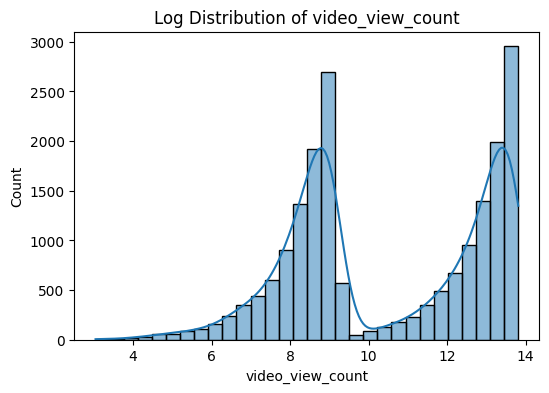

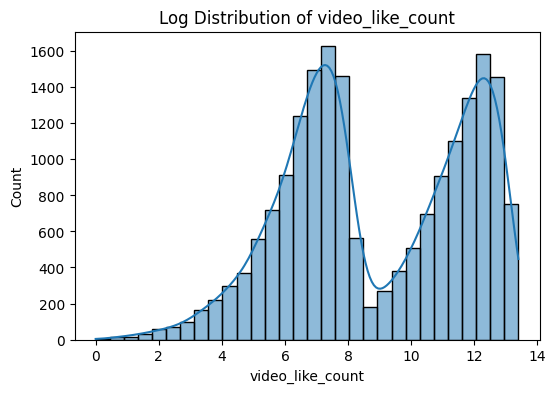

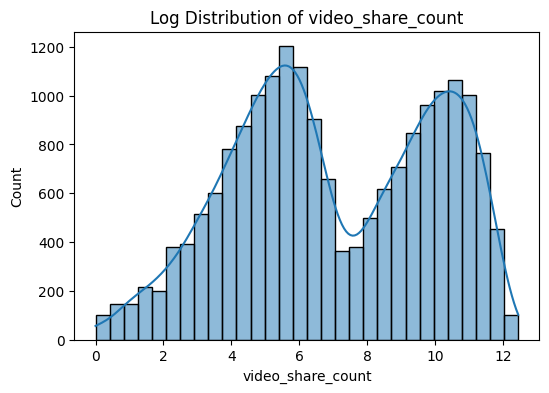

In [428]:
cols = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_duration_sec"
]
# Use log transformation to handle skewness
for col in ["video_view_count", "video_like_count", "video_share_count"]:
    plt.figure(figsize=(6,4))
    sns.histplot(np.log1p(df[col]), bins=30, kde=True)
    plt.title(f"Log Distribution of {col}")
    plt.show()

# Count plots of: 
- claim vs opinion
- verified vs not
- banned, under review or active 

In [429]:
selected_cols = [
    "claim_status",
    "verified_status",
    "author_ban_status"
]

for col in selected_cols:
    print("\n", "="*40)
    print(f" COLUMN: {col}")
    print("="*40)

    counts = df[col].value_counts(dropna=False)
    percent = df[col].value_counts(dropna=False, normalize=True) * 100

    result = pd.DataFrame({
        "count": counts,
        "percentage": percent.round(2).astype(str) + "%"
    })

    print(result)


 COLUMN: claim_status
              count percentage
claim_status                  
claim          9608     49.57%
opinion        9476     48.89%
unknown         298      1.54%

 COLUMN: verified_status
                 count percentage
verified_status                  
not verified     18142      93.6%
verified          1240       6.4%

 COLUMN: author_ban_status
                   count percentage
author_ban_status                  
active             15663     80.81%
under review        2080     10.73%
banned              1639      8.46%


## Bivariate Analysis

# claim_status vs engagement

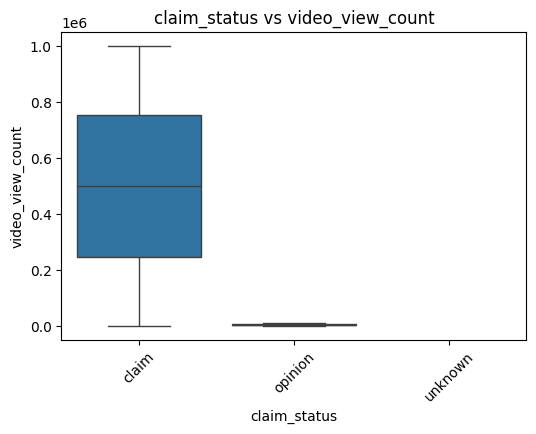

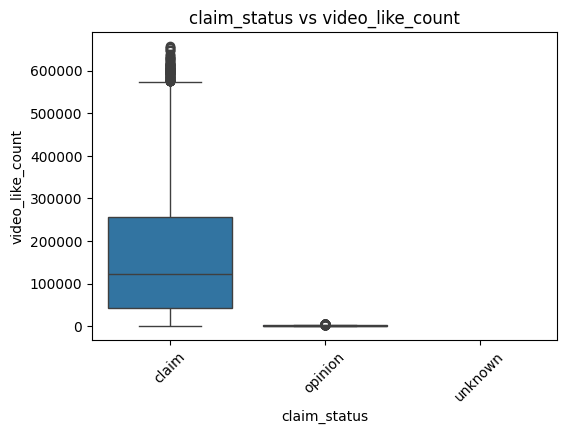

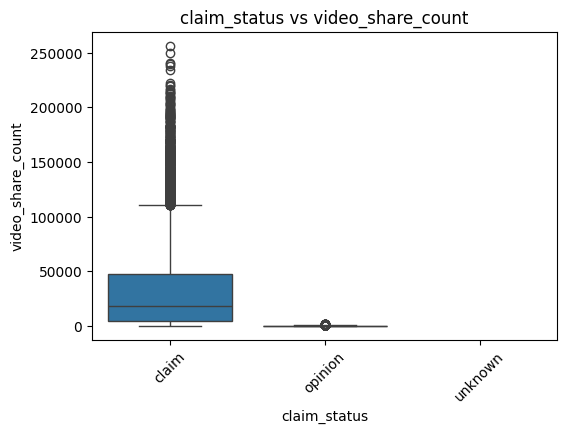

In [430]:
eng_cols = [
    "video_view_count",
    "video_like_count",
    "video_share_count"
]

for col in eng_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="claim_status", y=col)
    plt.title(f"claim_status vs {col}")
    plt.xticks(rotation=45)
    plt.show()

# verified_status vs views/likes

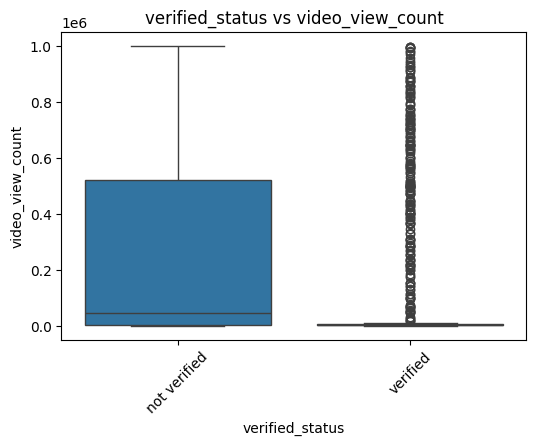

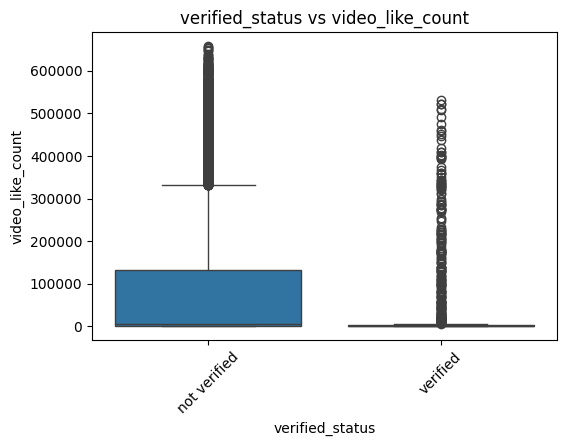

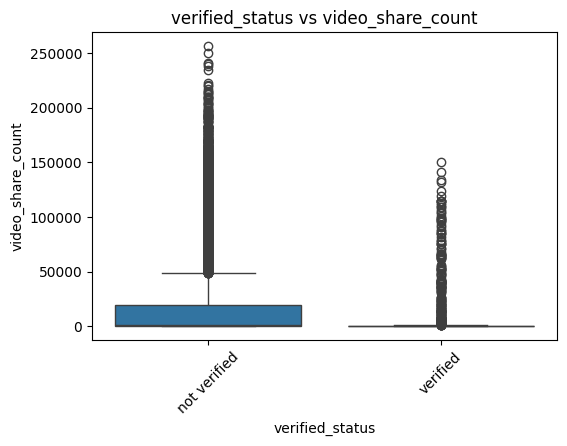

In [431]:
for col in eng_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="verified_status", y=col)
    plt.title(f"verified_status vs {col}")
    plt.xticks(rotation=45)
    plt.show()

# video_duration_sec vs engagement

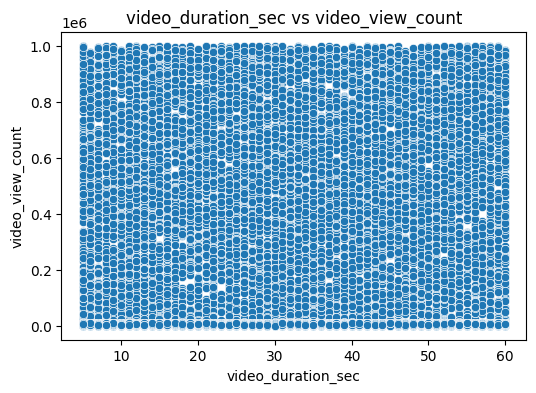

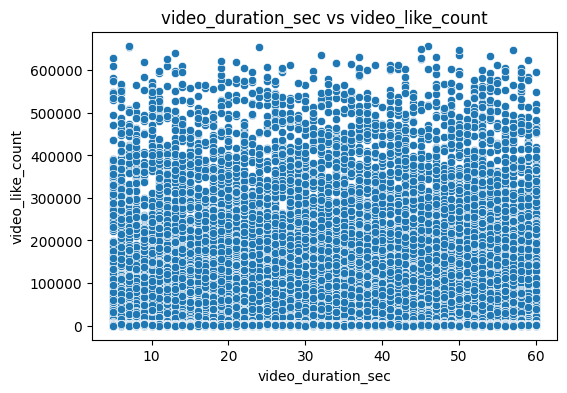

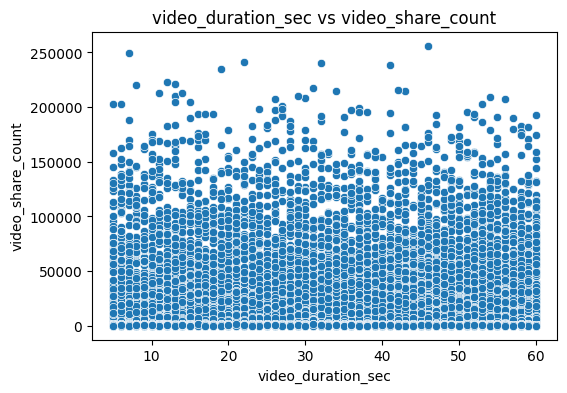

In [432]:
for col in eng_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x="video_duration_sec", y=col)
    plt.title(f"video_duration_sec vs {col}")
    plt.show()

# author_ban_status vs engagement

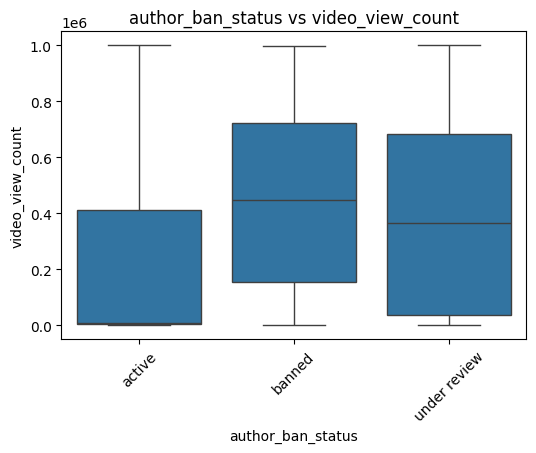

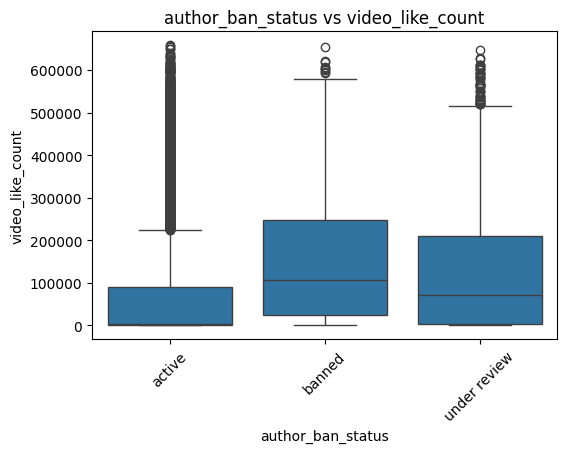

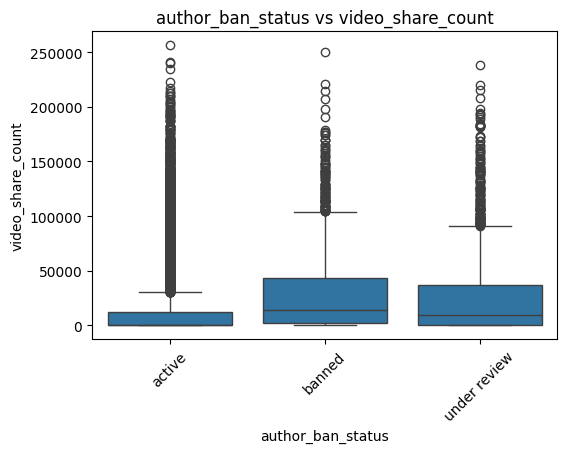

In [433]:
for col in eng_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="author_ban_status", y=col)
    plt.title(f"author_ban_status vs {col}")
    plt.xticks(rotation=45)
    plt.show()

# Grouped mean comparison

In [434]:
df.groupby("claim_status")[eng_cols].mean()

C:\Users\ronnr\AppData\Local\Temp\ipykernel_44496\722526198.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("claim_status")[eng_cols].mean()


,video_view_count,video_like_count,video_share_count
claim_status,,,
claim,501029.452748,166373.331182,33026.416216
opinion,4956.43225,1092.729844,217.145631
unknown,<NA>,<NA>,<NA>


In [435]:
df.groupby("verified_status")[eng_cols].mean()

C:\Users\ronnr\AppData\Local\Temp\ipykernel_44496\3976982784.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("verified_status")[eng_cols].mean()


,video_view_count,video_like_count,video_share_count
verified_status,,,
not verified,265663.785339,87925.772422,17415.888
verified,91439.164167,30337.633333,6591.448333


In [436]:
df.groupby("author_ban_status")[eng_cols].mean()

C:\Users\ronnr\AppData\Local\Temp\ipykernel_44496\2304447258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("author_ban_status")[eng_cols].mean()


,video_view_count,video_like_count,video_share_count
author_ban_status,,,
active,215927.039524,71036.533836,14111.466164
banned,445845.439144,153017.236697,29998.942508
under review,392204.836399,128718.050339,25774.696999


# **5. Feature Engineering**

# **6. Insights & Recommendations**
